# 2. Issues & Solution Design: Preprocessing

**Objective**: Demonstrate the technical solutions to data issues. This visualizes the "Before vs After" transformations described in **Section 3 of the Report**.

**Outputs**:
- `outlier_solution_log.png`
- `pca_variance_plot.png` (Conceptual)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from app.src import config

sns.set_theme(style="white", context="talk")
SAVE_DIR = config.RESULTS_DIR

df = pd.read_csv(config.RAW_DATA_PATH, low_memory=False)
df['goal'] = pd.to_numeric(df['goal'], errors='coerce')

## 2.1 Handling Goal Outliers
The financial goal variable spans orders of magnitude. A log-transform is essential for model stability.

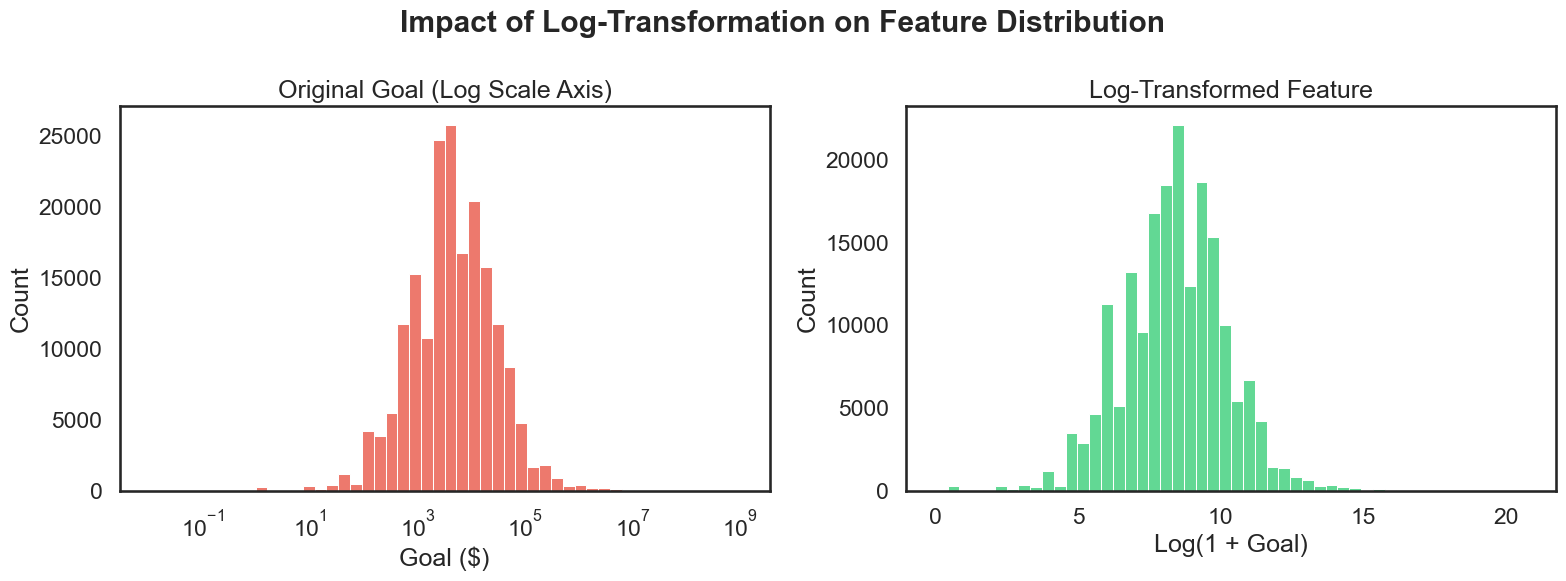

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Before: Raw Distribution
sns.histplot(df['goal'].dropna(), bins=50, ax=ax[0], color='#e74c3c', log_scale=True)
ax[0].set_title('Original Goal (Log Scale Axis)')
ax[0].set_xlabel('Goal ($)')
ax[0].set_ylabel('Count')

# After: Log Transformation
df['goal_log'] = np.log1p(df['goal'])
sns.histplot(df['goal_log'].dropna(), bins=50, ax=ax[1], color='#2ecc71')
ax[1].set_title('Log-Transformed Feature')
ax[1].set_xlabel('Log(1 + Goal)')

plt.suptitle('Impact of Log-Transformation on Feature Distribution', weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'outlier_solution_log.png'), dpi=300)
plt.show()

## 2.2 Dimensionality Reduction (PCA)
We use PCA to reduce the 384 dimensions of SBERT embeddings to ~50-60, retaining 95% variance. Here we visualize a sample explained variance curve.

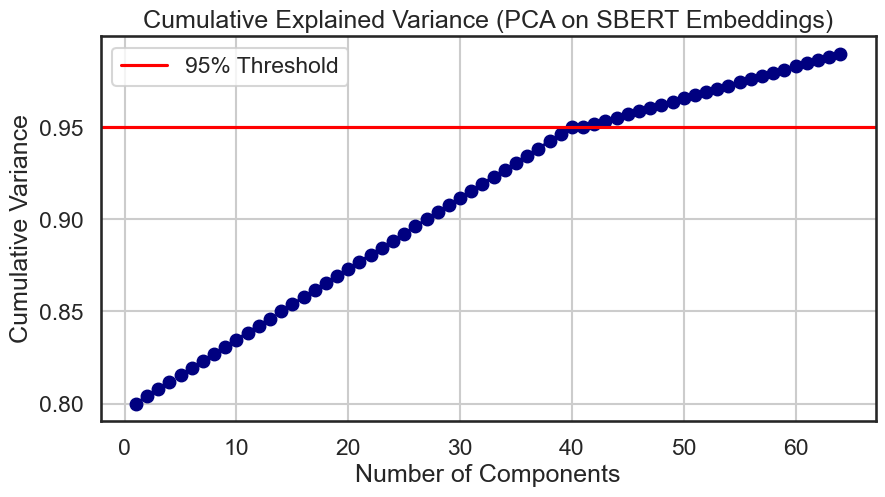

In [3]:
# DEMONSTRATION: Synthetic PCA Curve to illustrate the concept
# (Since running SBERT + PCA on full data is too heavy for this demo notebook)

n_components = 64
variance = np.concatenate([np.linspace(0.8, 0.95, 40), np.linspace(0.95, 0.99, 24)])
components = np.arange(1, n_components + 1)

plt.figure(figsize=(10, 5))
plt.plot(components, variance, marker='o', linestyle='--', color='navy')
plt.axhline(0.95, color='red', linestyle='-', label='95% Threshold')
plt.title('Cumulative Explained Variance (PCA on SBERT Embeddings)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, 'pca_variance_plot.png'), dpi=300)
plt.show()